# Multimodal Music Analysis

**Ομάδα:**
- Αθανάσιος Νικολέτας [sdi2300140]
- Αχιλλέας Πετρουλάκης [sdi2300171]


## 1.Installing dependances

In [1]:
%pip install seaborn
%pip install datasets
%pip install matplotlib
%pip install vaderSentiment
%pip install kneed
%pip install contractions
%pip install pyspellchecker
%pip install scikit-learn
%pip install pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2. Loading the files and extracting data

In [ ]:
import pandas as pd
import os

os.makedirs('../data/processed', exist_ok=True)

id_genres = pd.read_csv('../data/raw/id_genres.csv',sep='\t')
id_information = pd.read_csv('../data/raw/id_information.csv',sep='\t')
id_tags = pd.read_csv('../data/raw/id_tags.csv',sep='\t')


In [ ]:
chunks = []

for chunk in pd.read_csv('../data/raw/id_mfcc_stats.tsv.bz2',sep='\t',chunksize=500,compression='bz2'):
    chunks.append(chunk)

id_mfcc_stats = pd.concat(chunks, ignore_index=True)



,id,MFCC000,MFCC001,MFCC002,MFCC003,MFCC004,MFCC005,MFCC006,MFCC007,MFCC008,...,cov_9_9,cov_9_10,cov_9_11,cov_9_12,cov_10_10,cov_10_11,cov_10_12,cov_11_11,cov_11_12,cov_12_12
0,9EPCgcAlXdgiFsx4,20.640961,-5.828413,-6.140859,2.526664,-1.409552,2.681575,-2.989035,6.298501,3.528709,...,154.790424,21.799839,-15.056062,-19.218533,109.895439,26.262901,-4.037570,120.298222,18.571392,84.858156
1,9epP1yOXfLKlkR3S,24.351542,-16.611490,-10.792922,0.983246,-4.003687,-0.180248,-1.510487,-0.663130,2.915891,...,57.688839,20.511395,3.479626,-1.560816,63.036257,26.379835,2.551358,55.188890,18.194372,52.472903
2,9EPSUhPoRVOFU3WZ,20.963654,-10.754437,-17.771996,4.075799,-7.670935,7.884864,6.939635,-0.451056,1.786007,...,86.096650,21.553843,-21.785637,-28.995957,80.906525,15.235949,4.270046,92.649081,32.317742,94.037335
3,9eQ9CI53RilCiWe1,23.706192,-6.617346,-0.802629,-7.173328,-7.087190,1.222832,0.271057,5.402615,-1.984503,...,106.551662,27.140832,-25.204938,-15.030274,82.245596,6.003190,-0.670753,92.840371,31.832446,80.958201
4,9eQBXVI9m9OVpOzk,23.435280,-15.198643,-15.216316,6.386479,-1.970684,2.223027,3.663818,10.492731,3.448581,...,80.399399,27.589793,6.308148,-15.141247,81.638535,26.476400,-10.117312,70.432960,14.377084,68.796059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109264,Gi9mHOtYqqhBKAlq,22.397091,-5.621134,-9.448112,17.188934,3.683283,13.681705,4.782357,-1.423342,-5.413832,...,89.436025,12.007962,-1.372042,-10.793777,129.136233,67.722269,-3.807884,95.889554,17.795767,77.459253
109265,9emxothc6DRepCCU,24.246868,-10.500947,-3.747378,0.676189,3.654173,6.916228,4.306952,4.165692,0.648113,...,77.737938,13.658176,-7.732697,-8.974574,97.638720,32.069120,-10.460514,79.052539,13.197884,59.198772
109266,9eNdWAoixY1KGPHu,23.919300,9.303808,-3.472010,-1.501582,-8.757978,-12.899911,-1.934396,-6.120678,-8.051554,...,177.264556,2.410245,-15.062255,19.625713,188.697406,36.384346,1.931405,142.057252,36.653676,137.203147
109267,9EOGML1WNsQ0ryqa,20.672621,-9.151592,-7.972332,0.544694,-2.659995,-1.131967,-4.977994,0.916602,3.185759,...,74.385910,12.160347,-4.460289,-2.627358,89.835570,29.445522,-21.511069,62.031566,2.182601,57.626808


In [ ]:
id_mfcc_stats[id_mfcc_stats['id'] == '002Jyd0vN4HyCpqL']


## extracting processed_lyrics with tarfile and creating processed_lyrics dictionary

In [ ]:
import tarfile
from pathlib import Path

processed_lyrics_dict = {}
with tarfile.open('../data/raw/processed_lyrics.tar.gz', 'r:gz') as tar:
    for member in tar.getmembers():
        f = tar.extractfile(member)
        if f:
            song_id = Path(member.name).stem
            processed_lyrics_dict[song_id] = f.read().decode('utf-8')

processed_lyrics = pd.DataFrame(
    list(processed_lyrics_dict.items()),
    columns=['id', 'lyrics']
)

processed_lyrics




## Filtering 

In [ ]:
genre_exploded = id_genres.assign(
    genre=id_genres['genres'].str.split(',')
).explode('genre')
genre_exploded['genre'] = genre_exploded['genre'].str.strip()

top5_list = genre_exploded['genre'].value_counts().head(5).index.tolist()
print(top5_list)

# Exact match — only IDs where exploded genre is exactly in top5
chosen_ids = genre_exploded[genre_exploded['genre'].isin(top5_list)]['id']

chosen_song_ids = id_genres[id_genres['id'].isin(chosen_ids)]


processed_lyrics = processed_lyrics[processed_lyrics['lyrics'].str.len() >0]

full = chosen_song_ids.merge(processed_lyrics, on='id', how='inner').merge(id_mfcc_stats, on='id', how='inner')

full = full.sample(n=1000, random_state=42)

# print(chosen_song_ids['id'].iloc[0])
# print(processed_lyrics['id'].iloc[0])
# print(id_mfcc_stats['id'].iloc[0])


## Text Embeddings

In [ ]:
from gensim.models import Word2Vec
import gensim
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('punkt_tab')
import warnings

warnings.filterwarnings(action='ignore')

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

def preprocess_lyrics(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return tokens

full['tokens'] = full['lyrics'].apply(preprocess_lyrics)

display(full['tokens'])

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=full['tokens'].tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=20
)

# Document embeddings — average word vectors per song
def get_doc_embedding(tokens, model):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(model.wv.vector_size)

text_embeddings = np.array(full['tokens'].apply(lambda t: get_doc_embedding(t, w2v_model)).tolist())
print(f"Text embeddings shape: {text_embeddings.shape}")

[nltk_data] Downloading package punkt_tab to /home/thanos/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /home/thanos/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/thanos/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/thanos/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


42959    [brother, sister, unit, time, live, time, life...
45978    [want, freedom, world, street, sugar, let, sno...
18641    [say, dream, way, dream, way, explod, time, se...
4060     [thing, give, birth, world, thing, take, breat...
40359    [hello, dark, old, friend, come, talk, vision,...
                               ...                        
41866    [like, sailin, sailin, ship, nowher, love, tak...
3434     [could, fli, limp, bizkit, style, john, otto, ...
16470    [nobodi, ever, tell, final, chapter, stori, wi...
3077     [nowher, throw, lion, roar, loud, clear, make,...
1107     [penni, lane, barber, show, photograph, everi,...
Name: tokens, Length: 7500, dtype: object

Text embeddings shape: (7500, 100)


## Audio Ebbendings

In [144]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

mfcc_cols = [c for c in full.columns if c.startswith('MFCC') or c.startswith('cov_')]
audio_features = full[mfcc_cols].values

scaler = StandardScaler()
audio_scaled = scaler.fit_transform(audio_features)

pca = PCA(n_components=0.95)
audio_embeddings = pca.fit_transform(audio_scaled)

print(f"Original dims: {audio_features.shape[1]}")
print(f"PCA dims (95% variance): {audio_embeddings.shape[1]}")

Original dims: 104
PCA dims (95% variance): 79


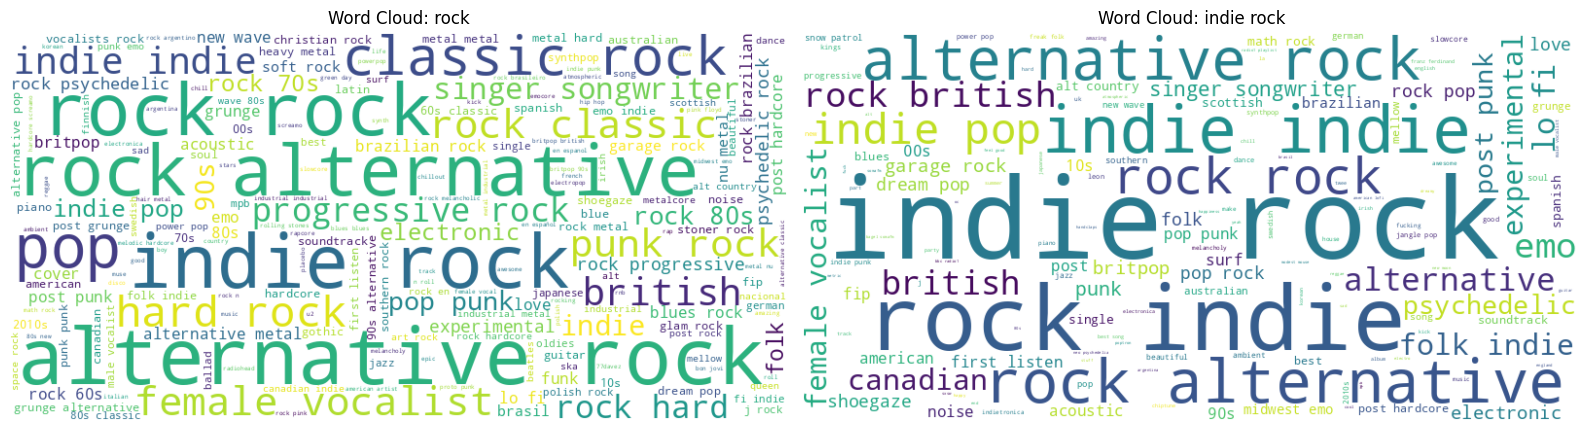

In [146]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Need tags — merge id_tags with full
full_tags = full.merge(id_tags, on='id', how='left')

# Pick 2 most different genres
genre_a, genre_b = top5_list[0], top5_list[-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, genre in zip(axes, [genre_a, genre_b]):
    genre_ids = full[full['genres'].str.contains(genre, na=False)]['id']
    tags_text = full_tags[full_tags['id'].isin(genre_ids)]['tags'].str.cat(sep=',')
    
    wc = WordCloud(width=800, height=400, background_color='white').generate(tags_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud: {genre}')
    ax.axis('off')

plt.tight_layout()
plt.show()

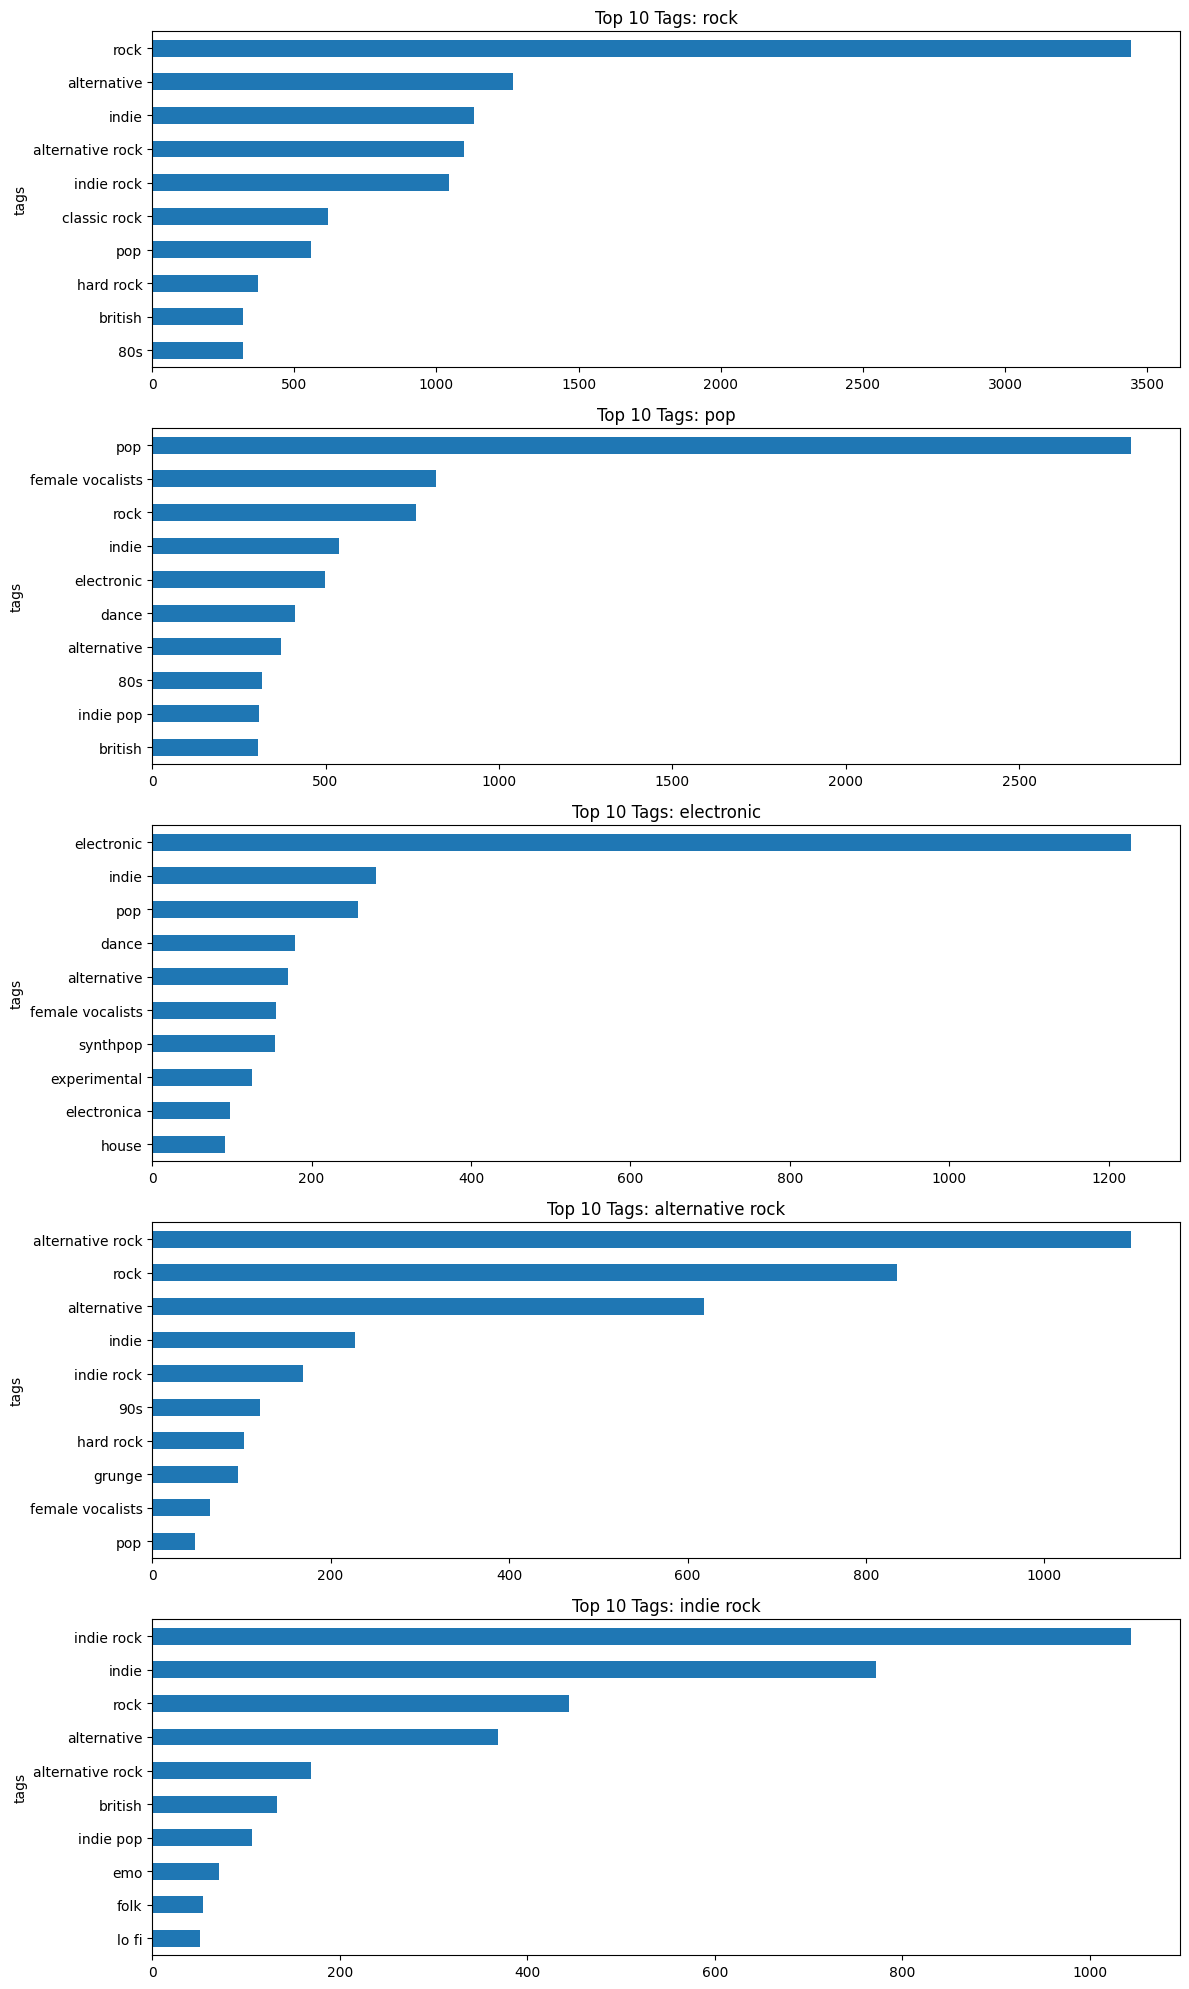

In [147]:
fig, axes = plt.subplots(len(top5_list), 1, figsize=(12, 4 * len(top5_list)))

for ax, genre in zip(axes, top5_list):
    genre_ids = full[full['genres'].str.contains(genre, na=False)]['id']
    genre_tags = full_tags[full_tags['id'].isin(genre_ids)]['tags'].str.split(',').explode().str.strip()
    top10 = genre_tags.value_counts().head(10)
    
    top10.plot(kind='barh', ax=ax)
    ax.set_title(f'Top 10 Tags: {genre}')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

/tmp/ipykernel_1847/2951782870.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full['primary_genre'] = full['genres'].str.split(',').str[0].str.strip()


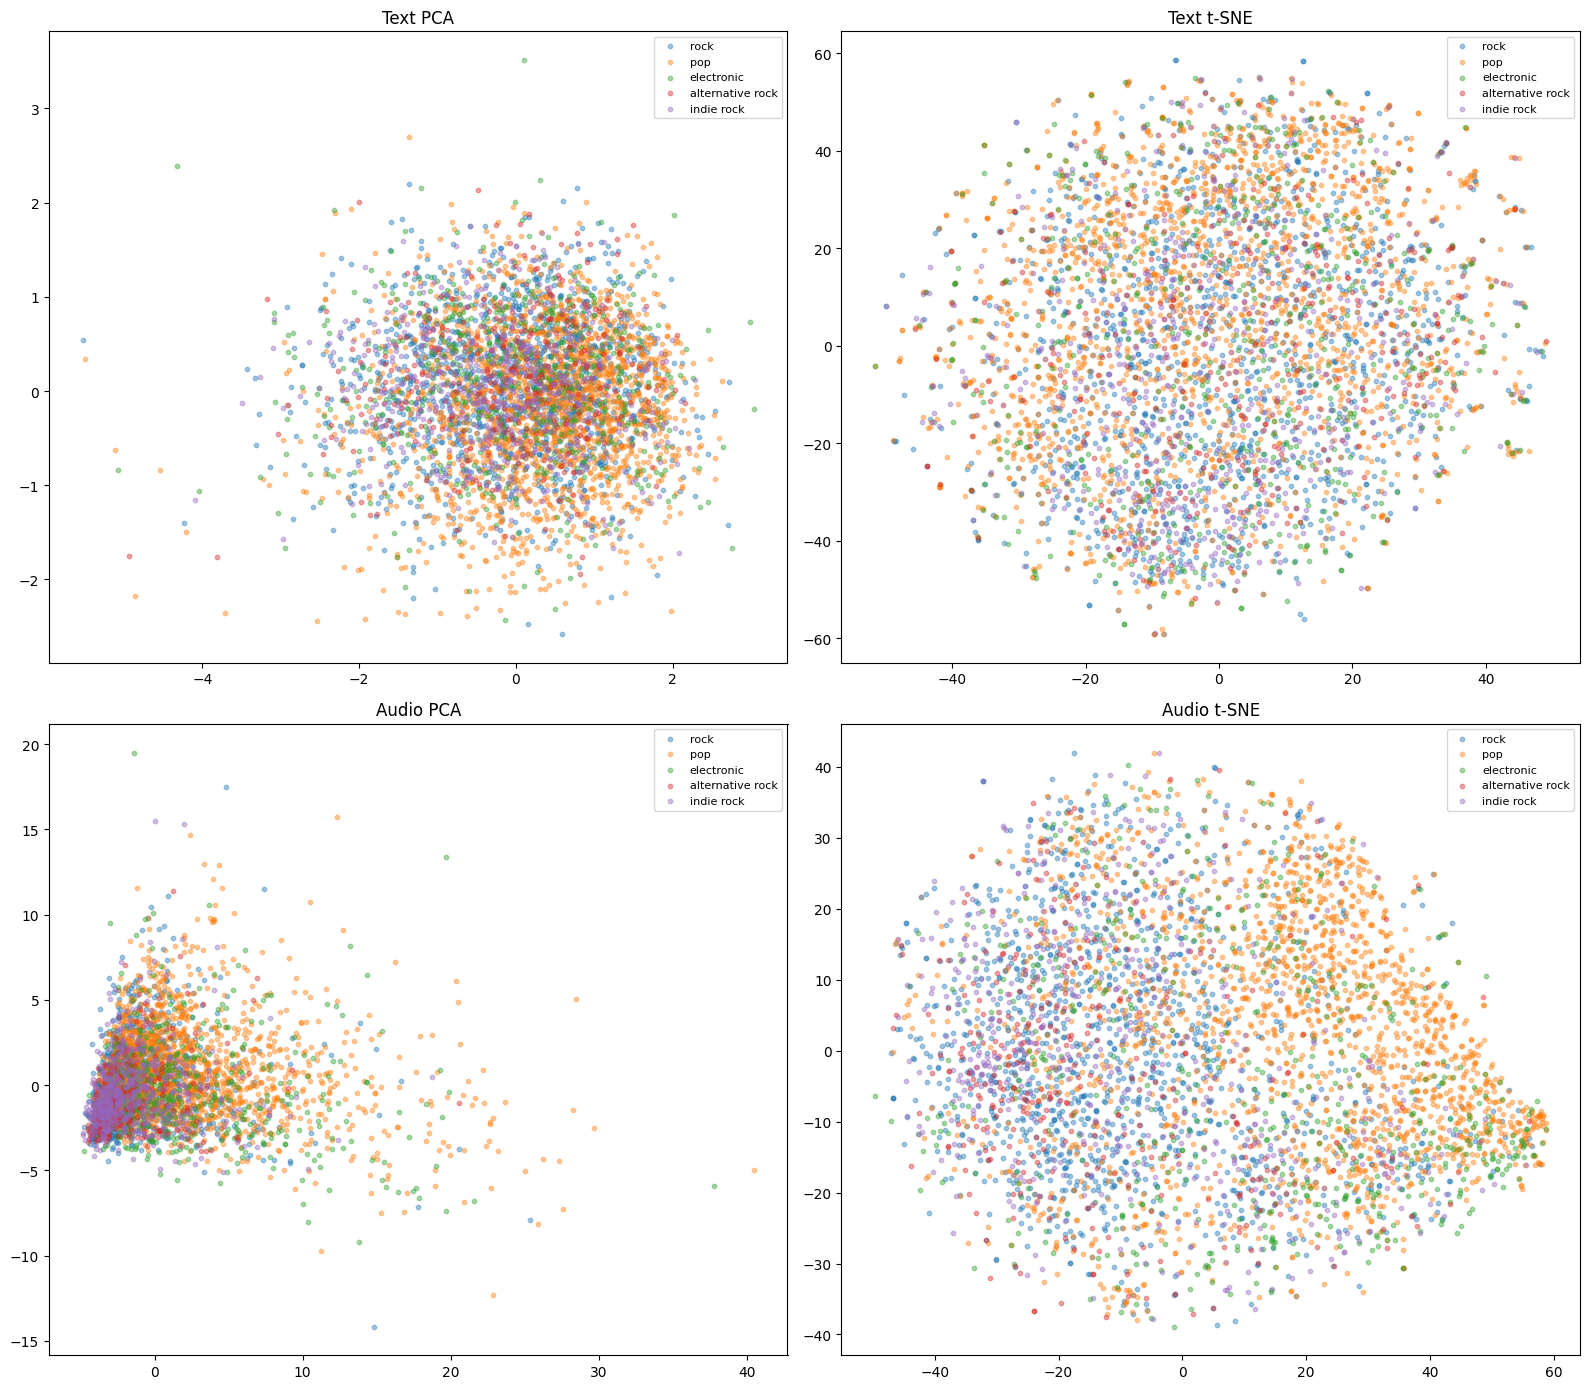

In [148]:
from sklearn.manifold import TSNE

# Assign primary genre for coloring
full['primary_genre'] = full['genres'].str.split(',').str[0].str.strip()

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Text PCA 2D
text_2d_pca = PCA(n_components=2).fit_transform(text_embeddings)
# Text t-SNE
text_2d_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(text_embeddings)
# Audio PCA 2D
audio_2d_pca = PCA(n_components=2).fit_transform(audio_embeddings)
# Audio t-SNE
audio_2d_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(audio_embeddings)

titles = ['Text PCA', 'Text t-SNE', 'Audio PCA', 'Audio t-SNE']
data = [text_2d_pca, text_2d_tsne, audio_2d_pca, audio_2d_tsne]

for ax, title, d in zip(axes.flat, titles, data):
    for genre in top5_list:
        mask = full['primary_genre'].values == genre
        ax.scatter(d[mask, 0], d[mask, 1], label=genre, alpha=0.4, s=10)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1847/1640946423.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full['genre_count'] = full['genres'].str.split(',').apply(len)


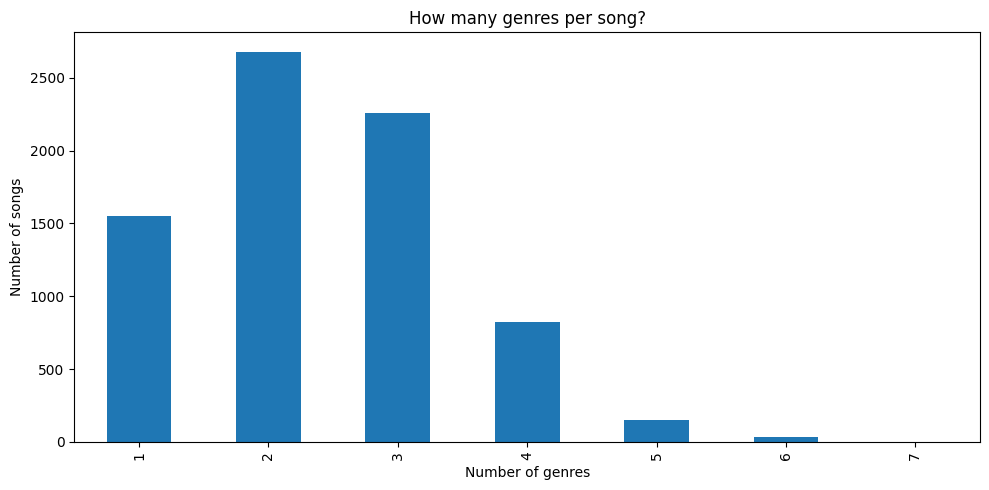

In [149]:
full['genre_count'] = full['genres'].str.split(',').apply(len)

fig, ax = plt.subplots(figsize=(10, 5))
full['genre_count'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel('Number of genres')
ax.set_ylabel('Number of songs')
ax.set_title('How many genres per song?')
plt.tight_layout()
plt.show()


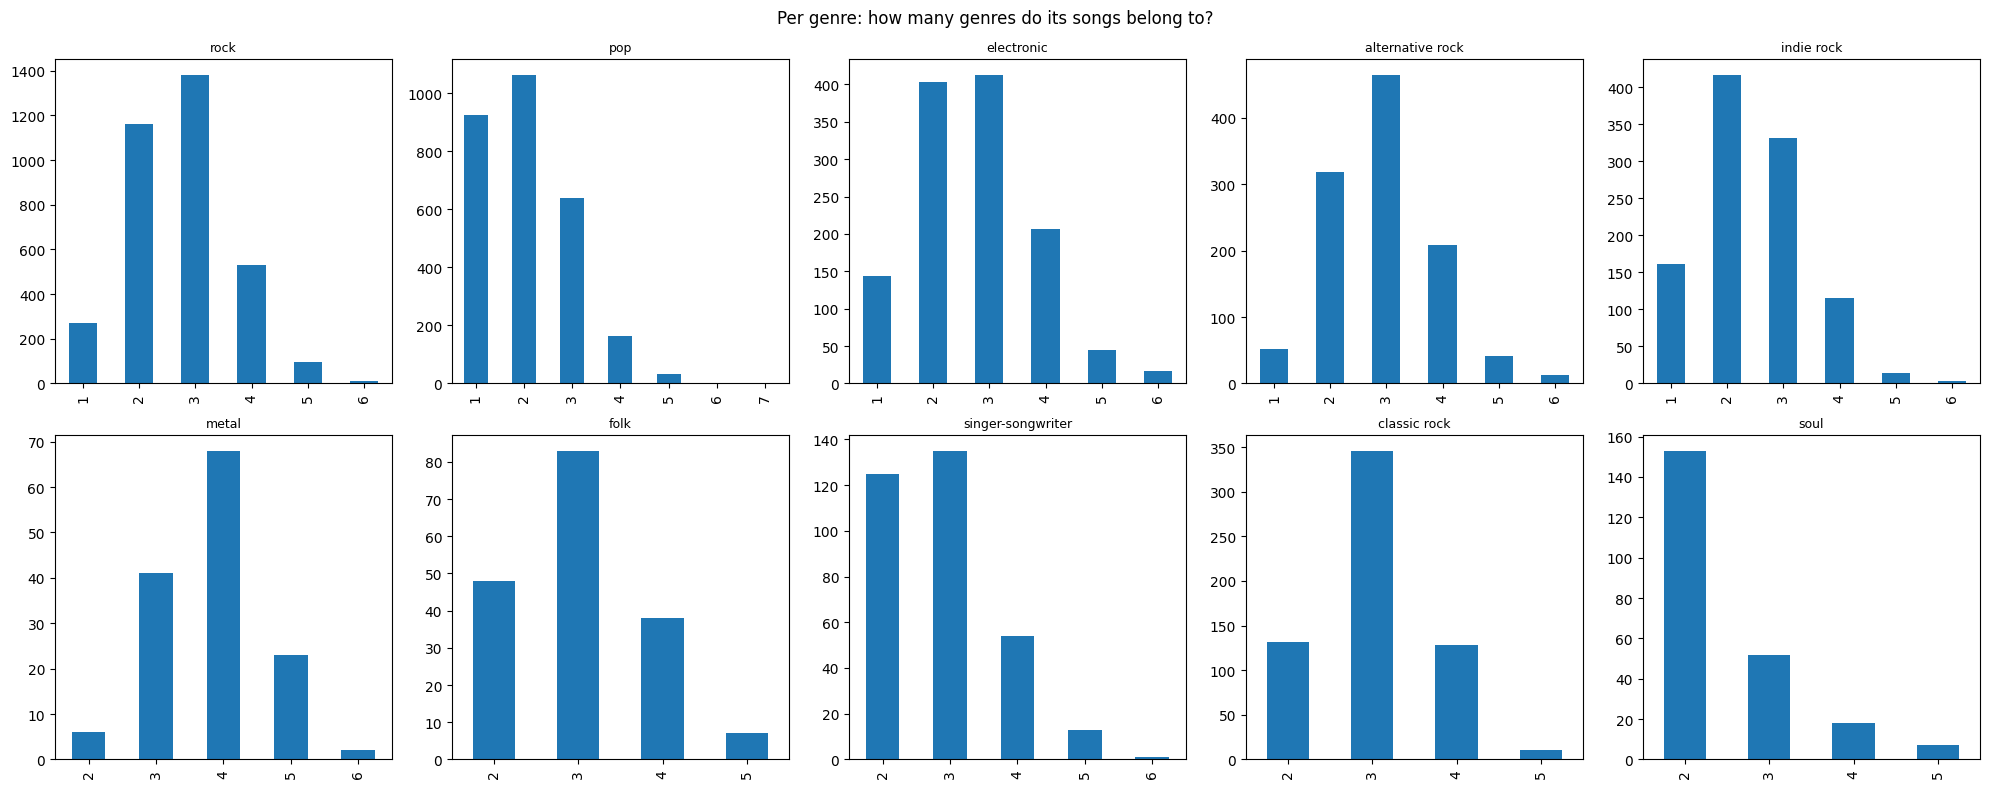

In [150]:
top10_genres = genre_exploded['genre'].value_counts().head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, genre in zip(axes.flat, top10_genres):
    genre_songs = genre_exploded[genre_exploded['genre'] == genre]['id']
    counts = full[full['id'].isin(genre_songs)]['genres'].str.split(',').apply(len)
    if len(counts) > 0:
        counts.value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(genre, fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Per genre: how many genres do its songs belong to?')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1847/1207018742.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full['word_count'] = full['lyrics'].str.split().apply(len)
/tmp/ipykernel_1847/1207018742.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full['char_count'] = full['lyrics'].str.len()
/tmp/ipykernel_1847/1207018742.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a 

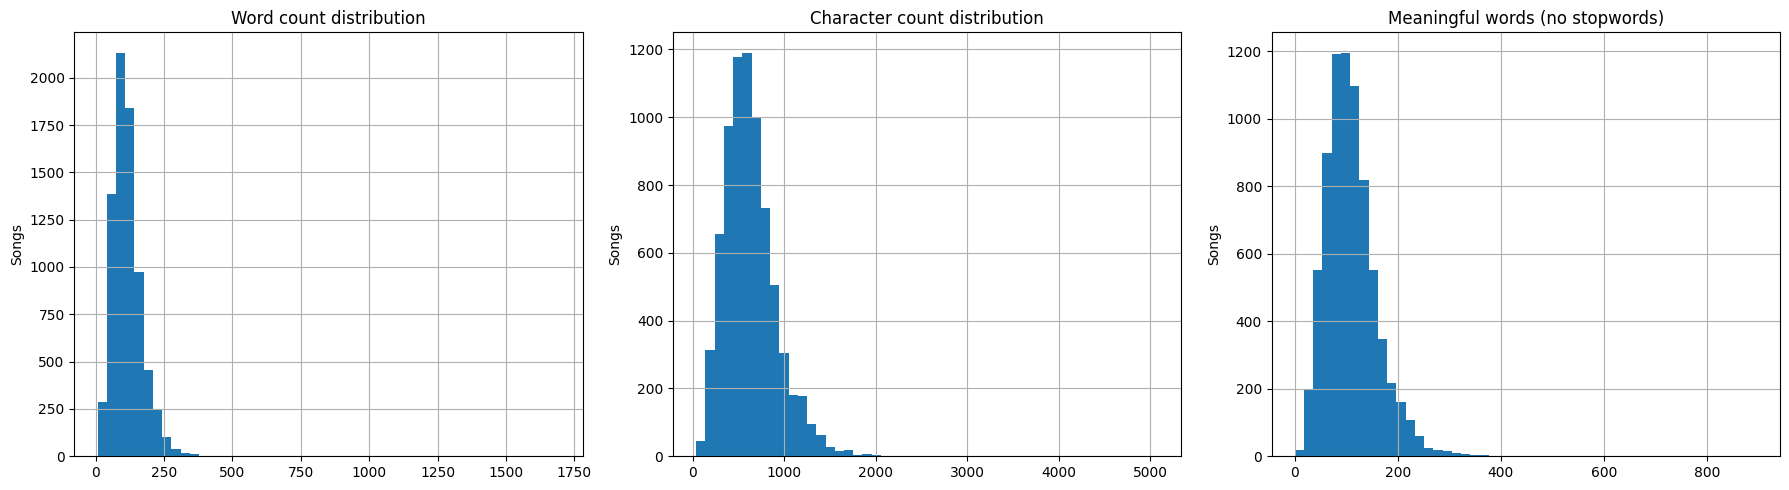

Avg words: 116, Avg meaningful: 110


In [151]:
full['word_count'] = full['lyrics'].str.split().apply(len)
full['char_count'] = full['lyrics'].str.len()
full['meaningful_words'] = full['tokens'].apply(len)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

full['word_count'].hist(bins=50, ax=axes[0])
axes[0].set_title('Word count distribution')

full['char_count'].hist(bins=50, ax=axes[1])
axes[1].set_title('Character count distribution')

full['meaningful_words'].hist(bins=50, ax=axes[2])
axes[2].set_title('Meaningful words (no stopwords)')

for ax in axes:
    ax.set_ylabel('Songs')

plt.tight_layout()
plt.show()

print(f"Avg words: {full['word_count'].mean():.0f}, Avg meaningful: {full['meaningful_words'].mean():.0f}")


In [152]:
from sklearn.metrics.pairwise import cosine_similarity

sample_idx = 0
sample = full.iloc[sample_idx]
print(f"Query: {sample['id']} | genre: {sample['genres']}\n")

# Text similarity
text_sim = cosine_similarity([text_embeddings[sample_idx]], text_embeddings)[0]
text_top5 = text_sim.argsort()[-6:-1][::-1]

print("Top 5 similar by LYRICS:")
for i in text_top5:
    r = full.iloc[i]
    print(f"  {r['id']} | {r['genres']} | sim: {text_sim[i]:.4f}")

# Audio similarity
audio_sim = cosine_similarity([audio_embeddings[sample_idx]], audio_embeddings)[0]
audio_top5 = audio_sim.argsort()[-6:-1][::-1]

print("\nTop 5 similar by AUDIO:")
for i in audio_top5:
    r = full.iloc[i]
    print(f"  {r['id']} | {r['genres']} | sim: {audio_sim[i]:.4f}")


Query: p57NIYlOER9ShCje | genre: rock,britpop,alternative rock

Top 5 similar by LYRICS:
  ZfBQquqWOihU7ykX | britpop,rock | sim: 0.9714
  VAGbVYpDCZe8KuYm | nu metal,rock,alternative rock,metal,hard rock | sim: 0.8368
  1MMLKM3p1GQwmNj3 | electronic | sim: 0.8339
  QUJ8zKT2xvrShIlP | classic rock,rock,soft rock | sim: 0.8318
  4edtfURJHArBQ9NO | progressive rock,classic rock,rock | sim: 0.8295

Top 5 similar by AUDIO:
  ZfBQquqWOihU7ykX | britpop,rock | sim: 1.0000
  HZs392QkmLezrFDR | rock | sim: 0.4081
  2ueJb7jjsNvxv9FA | rock,classic rock,pop,soft rock | sim: 0.4024
  fNHGdyMGoNWomVy5 | rock,indie rock | sim: 0.3983
  mE2cBRO5douAH96W | folk,singer-songwriter,rock,folk rock | sim: 0.3927
